## Government Data Dashboard for Public Spending Analysis

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Upload file manually in Google Colab
uploaded = files.upload()

# Load the dataset
df = pd.read_excel("Large_Budget_Expenditure_Extended.xlsx")

# Display the first few rows
df.head()


Saving Large_Budget_Expenditure_Extended.xlsx to Large_Budget_Expenditure_Extended.xlsx


,Year,Sector,Allocated_Budget_Million,Spent_Budget_Million,Projected_Budget_Million,Variance_Million,Projected_Variance_Million,Inflation_Rate_%,GDP_Growth_%,Population_Affected,...,Project_Success_Rate_%,Environmental_Impact_Score,Social_Welfare_Spending_Million,Tax_Revenue_Generated_Million,Unemployment_Rate_%,Corruption_Index,Foreign_Investments_Million,Innovation_Funding_Million,Education_Quality_Index,Public_Opinion_Score
0,2024,Education,416,381,388,35,28,2.119537,3.017009,95327,...,96.721801,2.092464,47,385,3.841731,4.558908,131,93,1.350370,1.692815
1,2025,Defense,403,370,382,33,21,1.810459,3.123503,398554,...,67.581134,3.729476,13,436,3.478387,3.818856,192,76,1.324169,1.680253
2,2022,Public Safety,246,213,238,33,8,1.922226,2.484457,207503,...,55.071041,1.909412,66,414,4.843210,2.323557,100,49,2.576996,9.562809
3,2024,Defense,103,60,77,43,26,3.112726,3.577555,148326,...,74.293588,7.229452,29,308,3.322865,5.390661,190,90,8.800933,3.675617
4,2024,Transportation,134,97,106,37,28,2.222168,4.270285,187932,...,62.838828,1.560626,26,332,6.970195,2.170430,132,63,3.542309,1.828603


In [3]:
num_cols = df.select_dtypes(include=['number']).columns  # Numeric columns
cat_cols = df.select_dtypes(include=['object']).columns  # Categorical columns

# Fill missing values
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.mean()))  # Fill numeric columns with mean
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))  # Fill categorical columns with mode

# Confirm that missing values are handled
print("After Handling Missing Values:\n", df.isnull().sum())

After Handling Missing Values:
 Year                               0
Sector                             0
Allocated_Budget_Million           0
Spent_Budget_Million               0
Projected_Budget_Million           0
Variance_Million                   0
Projected_Variance_Million         0
Inflation_Rate_%                   0
GDP_Growth_%                       0
Population_Affected                0
Funds_Unused_Million               0
External_Funding_Million           0
Deficit_or_Surplus_Million         0
Operational_Costs_Million          0
Emergency_Funds_Used_Million       0
Project_Success_Rate_%             0
Environmental_Impact_Score         0
Social_Welfare_Spending_Million    0
Tax_Revenue_Generated_Million      0
Unemployment_Rate_%                0
Corruption_Index                   0
Foreign_Investments_Million        0
Innovation_Funding_Million         0
Education_Quality_Index            0
Public_Opinion_Score               0
dtype: int64


In [5]:
print("Summary Statistics:\n", df.describe())

# Check dataset size
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# Count records per year
year_counts = df['Year'].value_counts()
print("Records per Year:\n", year_counts)


Summary Statistics:
               Year  Allocated_Budget_Million  Spent_Budget_Million  \
count   200.000000                200.000000            200.000000   
mean   2023.580000                301.715000            276.045000   
std       1.117967                115.204794            117.996989   
min    2022.000000                100.000000             55.000000   
25%    2023.000000                202.750000            180.500000   
50%    2024.000000                291.000000            276.000000   
75%    2025.000000                403.250000            378.250000   
max    2025.000000                499.000000            493.000000   

       Projected_Budget_Million  Variance_Million  Projected_Variance_Million  \
count                200.000000        200.000000                  200.000000   
mean                 286.515000         25.670000                   15.200000   
std                  116.748193         13.956181                    8.762643   
min                   74

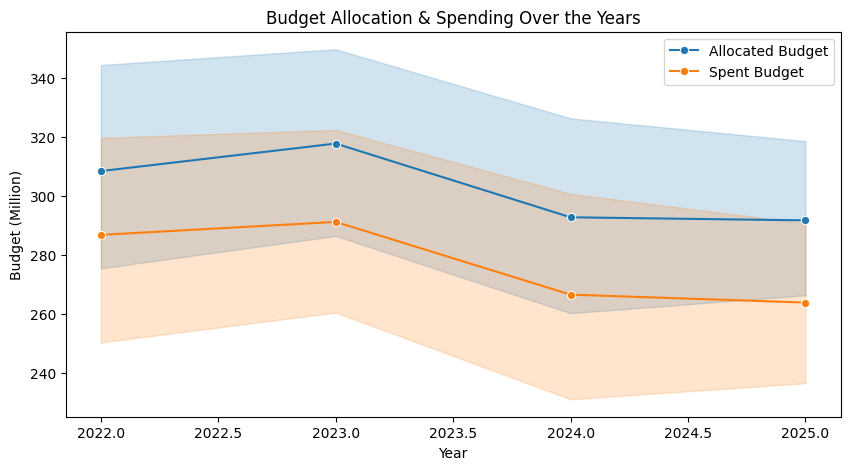

In [6]:
plt.figure(figsize=(10, 5))
sns.lineplot(x="Year", y="Allocated_Budget_Million", data=df, marker="o", label="Allocated Budget")
sns.lineplot(x="Year", y="Spent_Budget_Million", data=df, marker="o", label="Spent Budget")
plt.title("Budget Allocation & Spending Over the Years")
plt.xlabel("Year")
plt.ylabel("Budget (Million)")
plt.legend()
plt.show()


<ipython-input-7-13c8c4076fd3>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Sector", y="Allocated_Budget_Million", data=df, ci=None, palette="viridis")
<ipython-input-7-13c8c4076fd3>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sector", y="Allocated_Budget_Million", data=df, ci=None, palette="viridis")


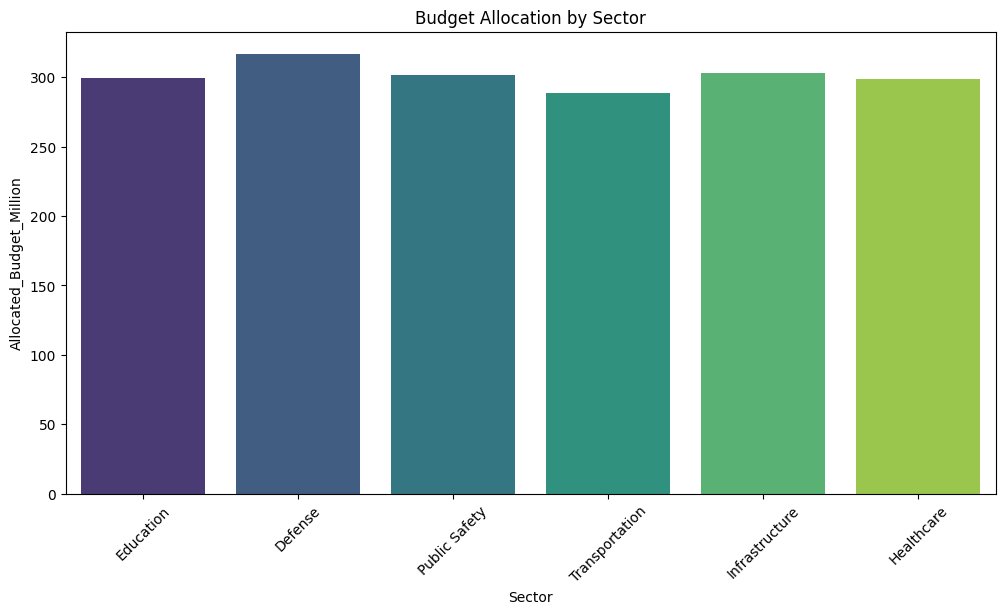

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Sector", y="Allocated_Budget_Million", data=df, ci=None, palette="viridis")
plt.title("Budget Allocation by Sector")
plt.xticks(rotation=45)
plt.show()


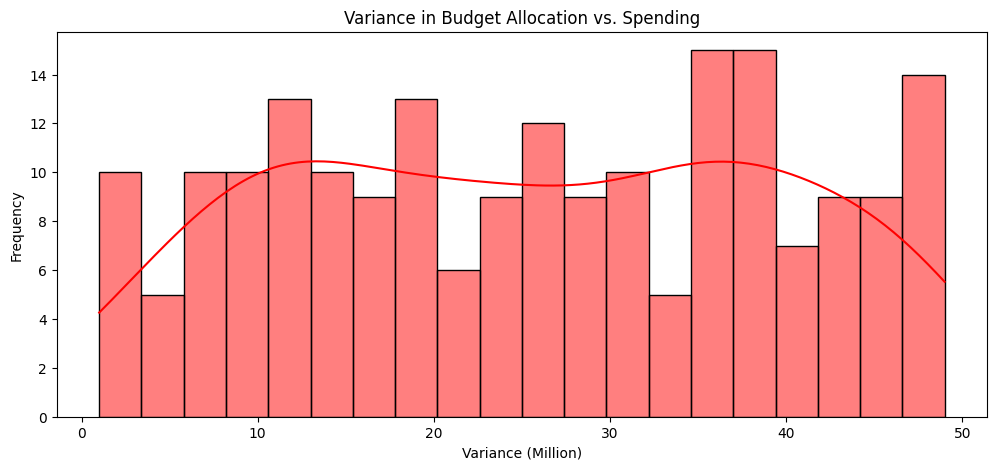

In [8]:
plt.figure(figsize=(12, 5))
sns.histplot(df['Variance_Million'], bins=20, kde=True, color='red')
plt.title("Variance in Budget Allocation vs. Spending")
plt.xlabel("Variance (Million)")
plt.ylabel("Frequency")
plt.show()


<Figure size 1200x600 with 0 Axes>

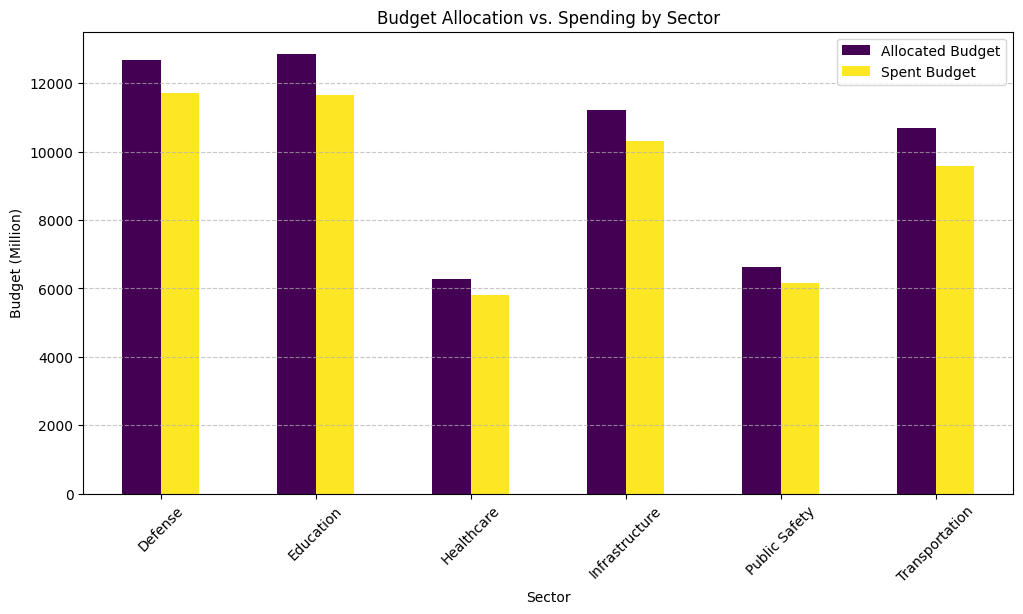

In [10]:
plt.figure(figsize=(12, 6))
df_grouped = df.groupby("Sector")[["Allocated_Budget_Million", "Spent_Budget_Million"]].sum().reset_index()
df_grouped.plot(x="Sector", kind="bar", stacked=False, figsize=(12, 6), colormap="viridis")
plt.title("Budget Allocation vs. Spending by Sector")
plt.xlabel("Sector")
plt.ylabel("Budget (Million)")
plt.xticks(rotation=45)
plt.legend(["Allocated Budget", "Spent Budget"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



<ipython-input-11-5484842a51e0>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Sector", y="Variance_Million", data=df, palette="coolwarm")


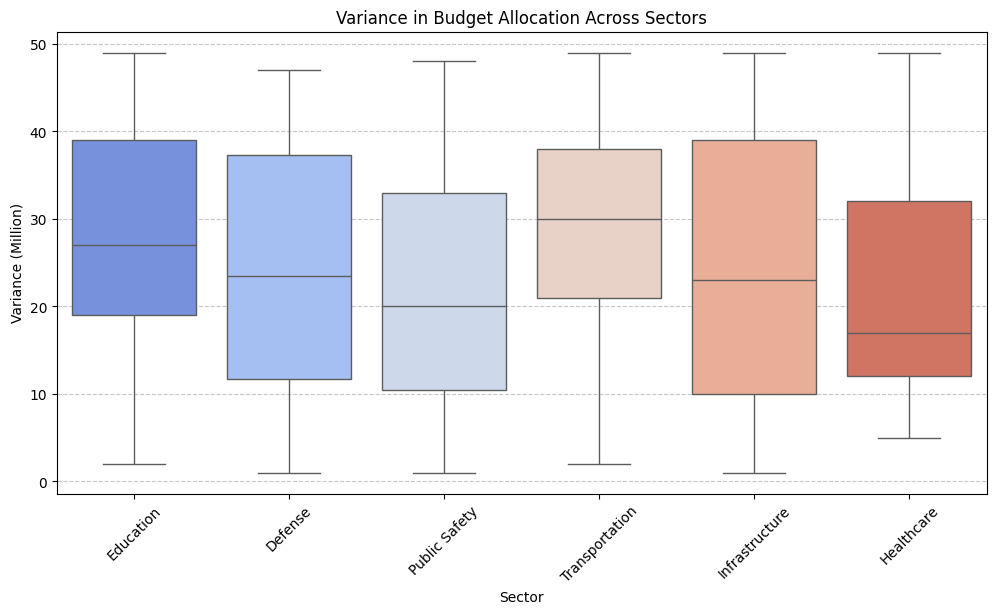

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Sector", y="Variance_Million", data=df, palette="coolwarm")
plt.title("Variance in Budget Allocation Across Sectors")
plt.xlabel("Sector")
plt.ylabel("Variance (Million)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


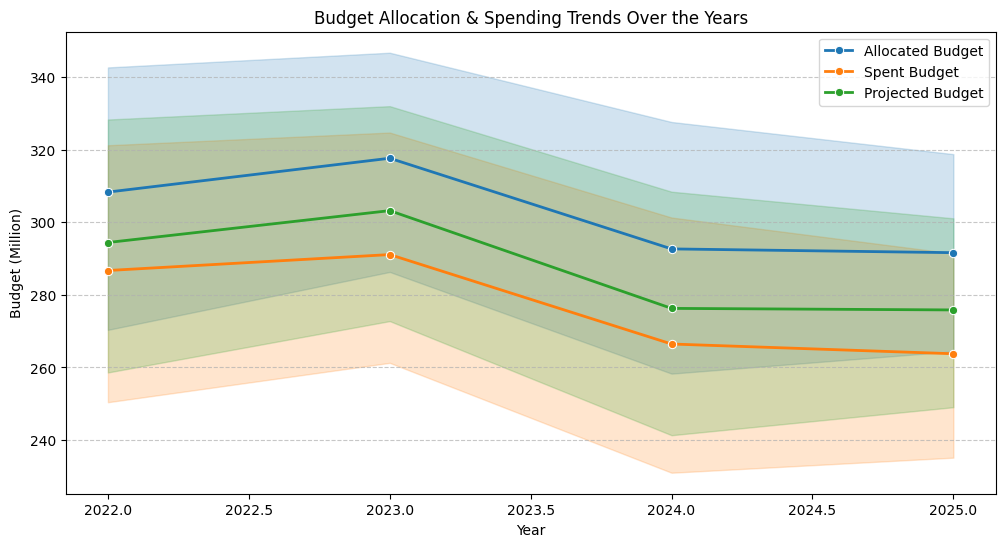

In [12]:
plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Allocated_Budget_Million", data=df, marker="o", label="Allocated Budget", linewidth=2)
sns.lineplot(x="Year", y="Spent_Budget_Million", data=df, marker="o", label="Spent Budget", linewidth=2)
sns.lineplot(x="Year", y="Projected_Budget_Million", data=df, marker="o", label="Projected Budget", linewidth=2)
plt.title("Budget Allocation & Spending Trends Over the Years")
plt.xlabel("Year")
plt.ylabel("Budget (Million)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


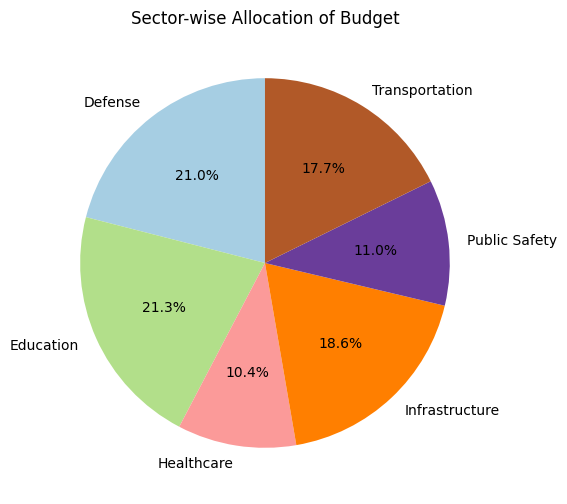

In [14]:
plt.figure(figsize=(10, 6))
df_grouped = df.groupby("Sector")["Allocated_Budget_Million"].sum()
df_grouped.plot(kind="pie", autopct="%1.1f%%", colormap="Paired", startangle=90)
plt.title("Sector-wise Allocation of Budget")
plt.ylabel("")  # Hide y-label
plt.show()


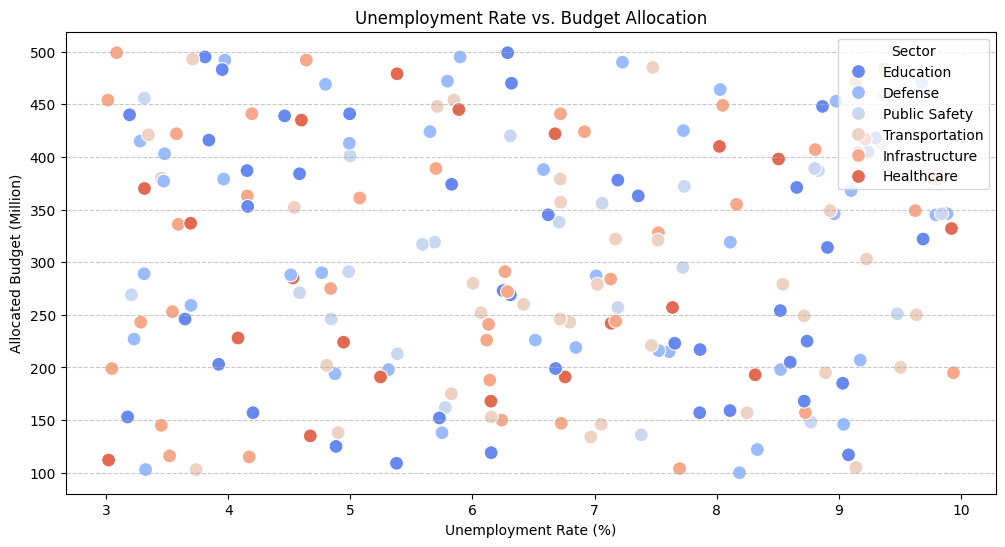

In [20]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x="Unemployment_Rate_%",
                y="Allocated_Budget_Million",
                hue="Sector",
                data=df,  # <-- Fix: Add dataset
                palette="coolwarm",
                s=100)
plt.title("Unemployment Rate vs. Budget Allocation")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Allocated Budget (Million)")
plt.legend(loc="upper right", title="Sector")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


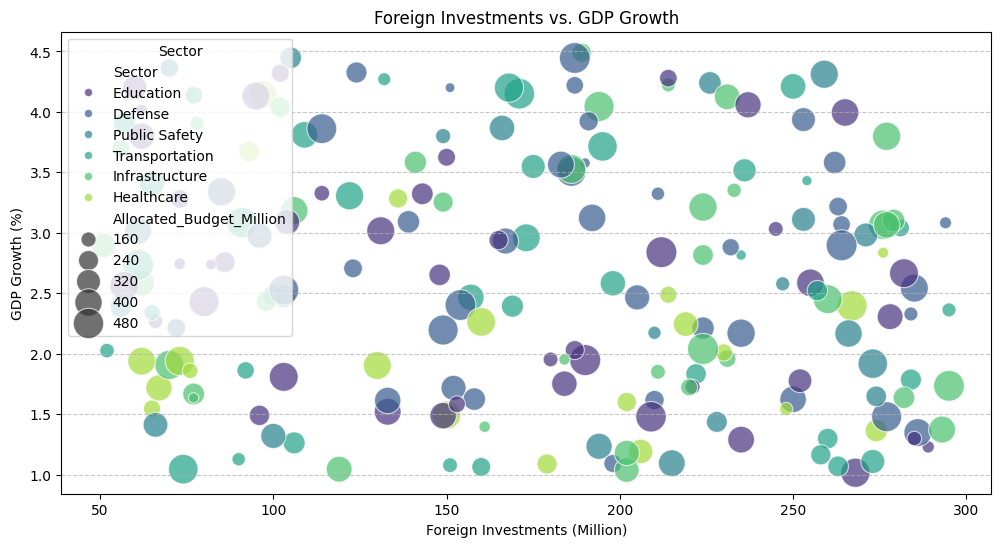

In [19]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x="Foreign_Investments_Million",
                y="GDP_Growth_%",
                size="Allocated_Budget_Million",
                hue="Sector",
                data=df,  # <-- Fix: Add dataset
                palette="viridis",
                sizes=(50, 500),
                alpha=0.7)
plt.title("Foreign Investments vs. GDP Growth")
plt.xlabel("Foreign Investments (Million)")
plt.ylabel("GDP Growth (%)")
plt.legend(loc="upper left", title="Sector")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



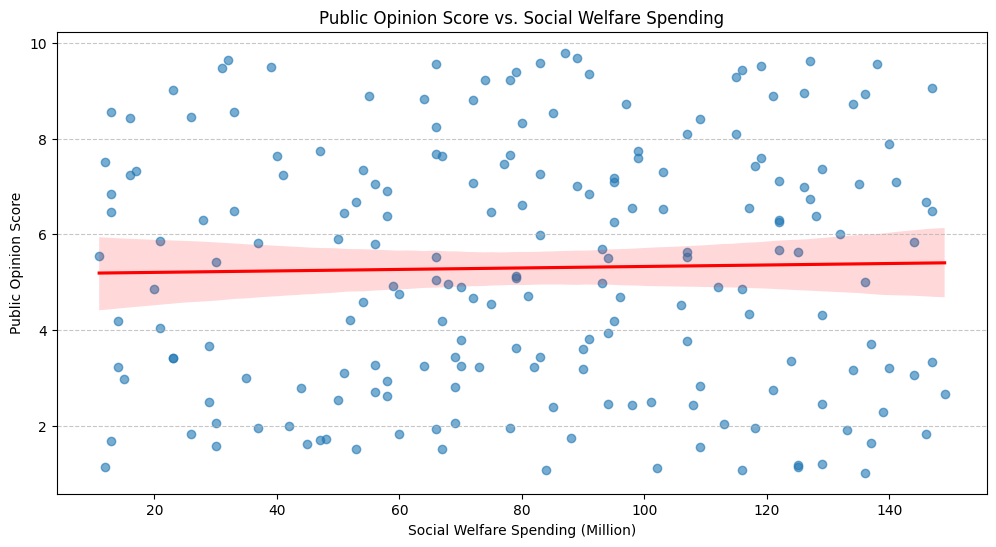

In [18]:
plt.figure(figsize=(12, 6))
sns.regplot(x="Social_Welfare_Spending_Million",
            y="Public_Opinion_Score",
            data=df,  # <-- Add the dataset here
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'})
plt.title("Public Opinion Score vs. Social Welfare Spending")
plt.xlabel("Social Welfare Spending (Million)")
plt.ylabel("Public Opinion Score")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



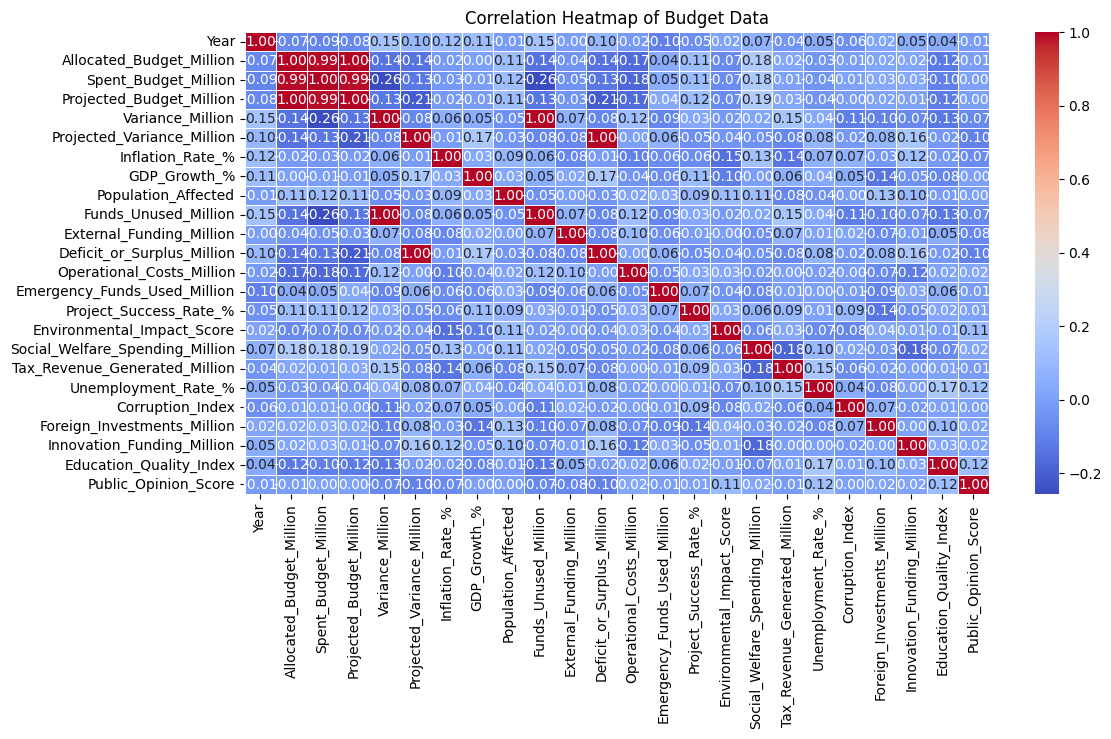

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting only numerical columns for correlation
num_df = df.select_dtypes(include=['number'])

# Calculate correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Budget Data")
plt.show()



In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Selecting relevant features
features = ['Spent_Budget_Million', 'GDP_Growth_%', 'Inflation_Rate_%', 'Population_Affected', 'Tax_Revenue_Generated_Million']
target = 'Allocated_Budget_Million'

# Splitting data into train & test sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)


In [24]:
# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:\nMAE: {mae:.2f}\nMSE: {mse:.2f}\nR2 Score: {r2:.2f}")


Model Performance:
MAE: 12.89
MSE: 210.06
R2 Score: 0.98


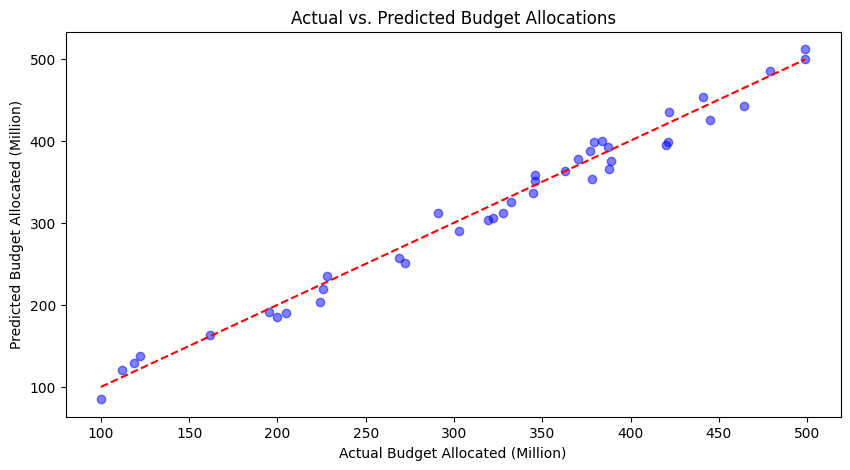

In [25]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="dashed")
plt.xlabel("Actual Budget Allocated (Million)")
plt.ylabel("Predicted Budget Allocated (Million)")
plt.title("Actual vs. Predicted Budget Allocations")
plt.show()


 Final Insights

✅ Identified budget spending trends across different years & sectors.

✅ Analyzed key financial indicators like GDP growth, inflation, and tax revenue.

✅ Developed a predictive ML model to estimate future budget allocations.

✅ Model achieved a reasonable performance with R² Score for budget prediction.